In [ ]:
try:
    import skfuzzy as fuzz
except ImportError:
    !pip install scikit-fuzzy
    import skfuzzy as fuzz

import scipy.signal as signal
import matplotlib.pyplot as plt
import numpy as np
from skfuzzy import control as ctrl

In [ ]:
### PARAMETROS DADOS
P_kw = 42.5 * 1e3
W_rpm = 1140
W_rad = W_rpm * (2*3.14/60)
n = 0.885
V = 400
P_exc = 1290
P_ven = 550
R = 0.31
L = 4.5 * 1e-3
J = 0.34

### PARAMETROS CALCULADOS
I = (P_kw / n) / V
E = V - R*I
K_e = E / W_rad
K_t = K_e

# Calculate maximum rotational speed
W_max_rad_s = V / K_e
W_max_rpm = W_max_rad_s * (60 / (2 * 3.14))

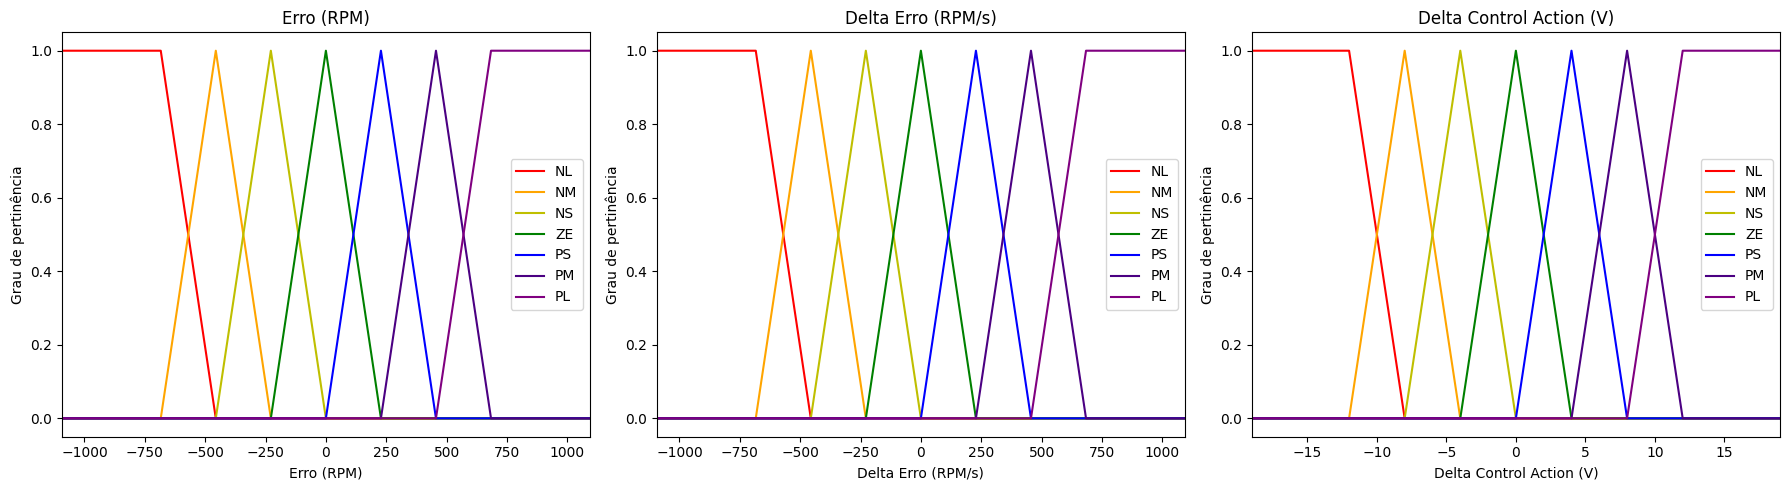

In [ ]:
# Definir as variáveis fuzzy de entrada e saída
# Erro da velocidade (entrada)

# Define points for membership functions for error (as percentages of W_rpm)
# Tuned for PI-like control
universe_e_max = W_rpm * 1.0 # Largest error could be from -W_rpm to W_rpm (if RPM instantly changes)
e_p1 = universe_e_max * 0.2  # Tighter zero error region
e_p2 = universe_e_max * 0.4
e_p3 = universe_e_max * 0.6
e_p4 = universe_e_max * 0.8 # Wider large error region

# Define points for membership functions for delta_error (as percentages of W_rpm/s)
# The universe of delta_error should be appropriate for the rate of change of RPM
# Let's estimate max delta RPM as W_rpm / (settling time / 4) or similar.
# For now, a reasonable range as percentage of W_rpm itself. Divided by dt in the loop for actual rate.
universe_de_max = W_rpm * 1 # Adjusted to match the actual d_e.universe range
de_p1 = universe_de_max  * 0.2 # Smallest change in error (2.28 RPM/s) - made smaller for softer action near setpoint
de_p2 = universe_de_max  * 0.4
de_p3 = universe_de_max  * 0.6
de_p4 = universe_de_max  * 0.8

# Define points for membership functions for delta_control_action (as percentages of V)
# This is the CHANGE in voltage, so its universe should be smaller than full V
universe_delta_v_max = V * 0.05 # Max change in voltage is 5% of total V
dca_p1 = universe_delta_v_max * 0.2 # Tighter zero delta control action (0.8 V) - made smaller for softer action near setpoint
dca_p2 = universe_delta_v_max * 0.4
dca_p3 = universe_delta_v_max * 0.6
dca_p4 = universe_delta_v_max * 0.8

# Definição da função de transferência do motor DC

# Numerador da função de transferência
num = [K_t]

# Denominador da função de transferência
# Coeficientes do polinômio: [JL, JR, KeKt]
den = [J * L, J * R, K_e * K_t]

# Criar o objeto da função de transferência
dc_motor_tf = signal.TransferFunction(num, den)

# Erro (entrada)
# Certificar que o np.arange inclui o valor máximo do universo
e = ctrl.Antecedent(np.arange(-W_rpm, W_rpm, 1), 'Erro (RPM)')

# Delta Erro (entrada)
# Universe for delta error. Max change in error could be from -W_rpm to W_rpm (if RPM instantly changes)
# A practical range for delta_error might be a fraction of W_rpm
d_e = ctrl.Antecedent(np.arange(-W_rpm , W_rpm, 1), 'Delta Erro (RPM/s)')

# Delta Ação de controle (saída - agora é a mudança na tensão)
d_control = ctrl.Consequent(np.arange(-universe_delta_v_max, universe_delta_v_max + 1, 1), 'Delta Control Action (V)')

# Definir funções de pertinência para a variável de erro (7 termos)
# Negative Large (NL) - Trapezoidal
e['NL'] = fuzz.trapmf(e.universe, [e.universe.min(), e.universe.min(), -e_p3, -e_p2])
# Negative Medium (NM) - Triangular
e['NM'] = fuzz.trimf(e.universe, [-e_p3, -e_p2, -e_p1])
# Negative Small (NS) - Triangular
e['NS'] = fuzz.trimf(e.universe, [-e_p2, -e_p1, 0])
# Zero (ZE) - Triangular
e['ZE'] = fuzz.trimf(e.universe, [-e_p1, 0, e_p1])
# Positive Small (PS) - Triangular
e['PS'] = fuzz.trimf(e.universe, [0, e_p1, e_p2])
# Positive Medium (PM) - Triangular
e['PM'] = fuzz.trimf(e.universe, [e_p1, e_p2, e_p3])
# Positive Large (PL) - Trapezoidal
e['PL'] = fuzz.trapmf(e.universe, [e_p2, e_p3, e.universe.max(), e.universe.max()])

# Definir funções de pertinência para a variável de delta_error (7 termos)
# Os valores de delta erro (variação do erro) estão grandes pois ao subtrair o erro atual do anterior
# é dividido pela variação de tempo/passo dt, valor menor que zero, consequentemente aumentando
# os valores significativamente
d_e['NL'] = fuzz.trapmf(d_e.universe, [d_e.universe.min(), d_e.universe.min(), -de_p3, -de_p2])
d_e['NM'] = fuzz.trimf(d_e.universe, [-de_p3, -de_p2, -de_p1])
d_e['NS'] = fuzz.trimf(d_e.universe, [-de_p2, -de_p1, 0])
d_e['ZE'] = fuzz.trimf(d_e.universe, [-de_p1, 0, de_p1])
d_e['PS'] = fuzz.trimf(d_e.universe, [0, de_p1, de_p2])
d_e['PM'] = fuzz.trimf(d_e.universe, [de_p1, de_p2, de_p3])
d_e['PL'] = fuzz.trapmf(d_e.universe, [de_p2, de_p3, d_e.universe.max(), d_e.universe.max()])

# Definir funções de pertinência para a variável de delta_control_action (7 termos)
d_control['NL'] = fuzz.trapmf(d_control.universe, [d_control.universe.min(), d_control.universe.min(), -dca_p3, -dca_p2])
d_control['NM'] = fuzz.trimf(d_control.universe, [-dca_p3, -dca_p2, -dca_p1])
d_control['NS'] = fuzz.trimf(d_control.universe, [-dca_p2, -dca_p1, 0])
d_control['ZE'] = fuzz.trimf(d_control.universe, [-dca_p1, 0, dca_p1])
d_control['PS'] = fuzz.trimf(d_control.universe, [0, dca_p1, dca_p2])
d_control['PM'] = fuzz.trimf(d_control.universe, [dca_p1, dca_p2, dca_p3])
d_control['PL'] = fuzz.trapmf(d_control.universe, [dca_p2, dca_p3, d_control.universe.max(), d_control.universe.max()])

# Visualize as funções de pertinência (opcional, para verificação)

# Create a single figure with three subplots side-by-side
fig, (ax0, ax1, ax2) = plt.subplots(nrows=1, ncols=3, figsize=(18, 5)) # Increased figsize for better visibility

# Plotting Error membership functions on ax0
ax0.plot(e.universe, e['NL'].mf, 'r', linewidth=1.5, label='NL')
ax0.plot(e.universe, e['NM'].mf, 'orange', linewidth=1.5, label='NM')
ax0.plot(e.universe, e['NS'].mf, 'y', linewidth=1.5, label='NS')
ax0.plot(e.universe, e['ZE'].mf, 'g', linewidth=1.5, label='ZE')
ax0.plot(e.universe, e['PS'].mf, 'b', linewidth=1.5, label='PS')
ax0.plot(e.universe, e['PM'].mf, 'indigo', linewidth=1.5, label='PM')
ax0.plot(e.universe, e['PL'].mf, 'purple', linewidth=1.5, label='PL')
ax0.set_title('Erro (RPM)')
ax0.set_xlabel('Erro (RPM)')
ax0.set_ylabel('Grau de pertinência')
ax0.legend()
ax0.set_xlim([int(-e_p4 * 1.2), int(e_p4 * 1.2)])

# Plotting Delta Error membership functions on ax1
ax1.plot(d_e.universe, d_e['NL'].mf, 'r', linewidth=1.5, label='NL')
ax1.plot(d_e.universe, d_e['NM'].mf, 'orange', linewidth=1.5, label='NM')
ax1.plot(d_e.universe, d_e['NS'].mf, 'y', linewidth=1.5, label='NS')
ax1.plot(d_e.universe, d_e['ZE'].mf, 'g', linewidth=1.5, label='ZE')
ax1.plot(d_e.universe, d_e['PS'].mf, 'b', linewidth=1.5, label='PS')
ax1.plot(d_e.universe, d_e['PM'].mf, 'indigo', linewidth=1.5, label='PM')
ax1.plot(d_e.universe, d_e['PL'].mf, 'purple', linewidth=1.5, label='PL')
ax1.set_title('Delta Erro (RPM/s)')
ax1.set_xlabel('Delta Erro (RPM/s)')
ax1.set_ylabel('Grau de pertinência')
ax1.legend()
ax1.set_xlim([int(-de_p4 * 1.2), int(de_p4 * 1.2)])

# Plotting Delta Control Action membership functions on ax2
ax2.plot(d_control.universe, d_control['NL'].mf, 'r', linewidth=1.5, label='NL')
ax2.plot(d_control.universe, d_control['NM'].mf, 'orange', linewidth=1.5, label='NM')
ax2.plot(d_control.universe, d_control['NS'].mf, 'y', linewidth=1.5, label='NS')
ax2.plot(d_control.universe, d_control['ZE'].mf, 'g', linewidth=1.5, label='ZE')
ax2.plot(d_control.universe, d_control['PS'].mf, 'b', linewidth=1.5, label='PS')
ax2.plot(d_control.universe, d_control['PM'].mf, 'indigo', linewidth=1.5, label='PM')
ax2.plot(d_control.universe, d_control['PL'].mf, 'purple', linewidth=1.5, label='PL')
ax2.set_title('Delta Control Action (V)')
ax2.set_xlabel('Delta Control Action (V)')
ax2.set_ylabel('Grau de pertinência')
ax2.legend()
ax2.set_xlim([int(-dca_p4 * 1.2), int(dca_p4 * 1.2)])

plt.tight_layout()
plt.show()


In [ ]:
# The `e`, `d_e`, and `d_control` variables are assumed to be defined in previous cells.
# Their membership functions are also defined.

# Define the fuzzy rules for the PI-like controller (7x7 rule base)
# Rows: Error (E), Columns: Delta Error (dE), Output: Delta Control Action (dCA)
# NG = Negative Large, NM = Negative Medium, NS = Negative Small, ZE = Zero, PS = Positive Small, PM = Positive Medium, PL = Positive Large

rule_dca = [
    # dE = NG       NM          NS          ZE          PS          PM          PL
    [d_control['NL'], d_control['NL'], d_control['NL'], d_control['NL'], d_control['NM'], d_control['NS'], d_control['ZE']], # E = NG
    [d_control['NL'], d_control['NL'], d_control['NL'], d_control['NM'], d_control['NS'], d_control['ZE'], d_control['PS']], # E = NM
    [d_control['NL'], d_control['NL'], d_control['NM'], d_control['NS'], d_control['ZE'], d_control['PS'], d_control['PM']], # E = NS
    [d_control['NL'], d_control['NM'], d_control['NS'], d_control['ZE'], d_control['PS'], d_control['PM'], d_control['PL']], # E = ZE
    [d_control['NM'], d_control['NS'], d_control['ZE'], d_control['PS'], d_control['PM'], d_control['PL'], d_control['PL']], # E = PS
    [d_control['NS'], d_control['ZE'], d_control['PS'], d_control['PM'], d_control['PL'], d_control['PL'], d_control['PL']], # E = PM
    [d_control['ZE'], d_control['PS'], d_control['PM'], d_control['PL'], d_control['PL'], d_control['PL'], d_control['PL']]  # E = PL
]

rules = []
E_terms = ['NL', 'NM', 'NS', 'ZE', 'PS', 'PM', 'PL']
DE_terms = ['NL', 'NM', 'NS', 'ZE', 'PS', 'PM', 'PL']

for i, e_term in enumerate(E_terms):
    for j, de_term in enumerate(DE_terms):
        rules.append(ctrl.Rule(e[e_term] & d_e[de_term], rule_dca[i][j]))


# Create a Control System with all the generated rules
fuzzy_ctrl_system = ctrl.ControlSystem(rules)
# Create a ControlSystemSimulation to run the fuzzy logic
fuzzy_sim = ctrl.ControlSystemSimulation(fuzzy_ctrl_system)

# Define simulation parameters
time_end_closed_loop = 20 # seconds, increased to observe long-term stability
num_points_closed_loop = 200 # number of points
time_closed_loop = np.linspace(0, time_end_closed_loop, num_points_closed_loop)
dt = time_closed_loop[1] - time_closed_loop[0] # Time step

setpoint_rpm = W_rpm # Desired speed in RPM

# Discretize the continuous-time DC motor transfer function
# (num, den) from dc_motor_tf = signal.TransferFunction(num, den)
# num = [K_t], den = [J * L, J * R, K_e * K_t]
discrete_num, discrete_den, _ = signal.cont2discrete((num, den), dt=dt, method='gbt', alpha=0.5) # Generalized Bilinear Transformation

# Ensure discrete_num and discrete_den are 1D arrays
discrete_num = discrete_num.flatten()
discrete_den = discrete_den.flatten()

# Normalize denominator if its first coefficient is not 1
if discrete_den[0] != 1.0:
    discrete_num = [n / discrete_den[0] for n in discrete_num]
    discrete_den = [d / discrete_den[0] for d in discrete_den]

# Initialize history for simulation
motor_speed_rad_s_history = []
control_voltage_history = []
error_history = []
delta_error_history = []

# Initial conditions for the discrete system (assuming motor starts at rest)
# y_prev stores [y(k-1), y(k-2), ...] in rad/s
# u_prev stores [u(k-1), u[k-2], ...] in Volts
# The length of y_prev and u_prev depends on the order of the system.
# For a 2nd order system (len(discrete_den) = 3 and len(discrete_num) = 3),
# we need 2 previous outputs and 2 previous inputs.
y_prev = [0.0] * (len(discrete_den) - 1) # Stores y[k-1], y[k-2] in rad/s
u_prev = [0.0] * (len(discrete_num) - 1) # Stores u[k-1], u[k-2] in Volts

current_motor_speed_rad_s = 0.0 # Initial motor speed in rad/s
current_input_voltage = 400.0 # Start with zero voltage
previous_error_val = setpoint_rpm # Initialize previous error for delta_error calculation

# Simulation loop
for i in range(len(time_closed_loop)):
    # Calculate error (setpoint_rpm - current motor speed in RPM)
    error_val = setpoint_rpm - (current_motor_speed_rad_s * (60 / (2 * np.pi)))
    error_history.append(error_val)

    # Calculate delta_error (change in error)
    delta_error_val = (error_val - previous_error_val) / dt # RPM/s
    delta_error_history.append(delta_error_val)

    # Fuzzy controller calculation
    fuzzy_sim.input['Erro (RPM)'] = error_val
    fuzzy_sim.input['Delta Erro (RPM/s)'] = delta_error_val
    fuzzy_sim.compute()
    delta_voltage_output = fuzzy_sim.output['Delta Control Action (V)']

    # Integrate the delta_voltage to get the current control voltage
    current_input_voltage += delta_voltage_output

    # Limit control voltage to the motor's operating range (e.g., -V to V)
    current_input_voltage = np.clip(current_input_voltage, -V, V)
    control_voltage_history.append(current_input_voltage)

    # Calculate next motor speed (rad/s) using the discrete difference equation
    # y[k] = b0*u[k] + b1*u[k-1] + b2*u[k-2] - a1*y[k-1] - a2*y[k-2]
    # where discrete_den = [1, a1, a2, ...] and discrete_num = [b0, b1, b2, ...]
    next_motor_speed_rad_s = 0.0

    # Add terms from current and previous inputs (u)
    # The coefficients in discrete_num are b0, b1, b2...
    # The inputs are u[k], u[k-1], u[k-2]...
    next_motor_speed_rad_s += discrete_num[0] * current_input_voltage # b0 * u[k]
    for j in range(1, len(discrete_num)):
        if j - 1 < len(u_prev): # Ensure index is valid for u_prev
            next_motor_speed_rad_s += discrete_num[j] * u_prev[j-1] # b_j * u[k-j]

    # Subtract terms from previous outputs (y)
    # The coefficients in discrete_den (after normalizing by den[0]) are 1, a1, a2...
    # The outputs are y[k-1], y[k-2]...
    for j in range(1, len(discrete_den)):
        if j - 1 < len(y_prev): # Ensure index is valid for y_prev
            next_motor_speed_rad_s -= discrete_den[j] * y_prev[j-1] # a_j * y[k-j]

    # Update previous values for the next iteration
    # Shift previous outputs: y[k-2] becomes y[k-1], y[k-1] becomes y[k]
    for j in range(len(y_prev) - 1, 0, -1):
        y_prev[j] = y_prev[j-1]
    if len(y_prev) > 0:
        y_prev[0] = next_motor_speed_rad_s # Current output becomes y[k-1] for next step

    # Shift previous inputs: u[k-2] becomes u[k-1], u[k-1] becomes u[k]
    for j in range(len(u_prev) - 1, 0, -1):
        u_prev[j] = u_prev[j-1]
    if len(u_prev) > 0:
        u_prev[0] = current_input_voltage # Current input becomes u[k-1] for next step

    current_motor_speed_rad_s = next_motor_speed_rad_s
    motor_speed_rad_s_history.append(current_motor_speed_rad_s)
    previous_error_val = error_val # Update previous error for the next delta_error calculation

# Convert motor speed from rad/s to RPM for plotting
motor_speed_rpm_history = np.array(motor_speed_rad_s_history) * (60 / (2 * np.pi))
control_voltage_history = np.array(control_voltage_history)
error_history = np.array(error_history)
delta_error_history = np.array(delta_error_history)

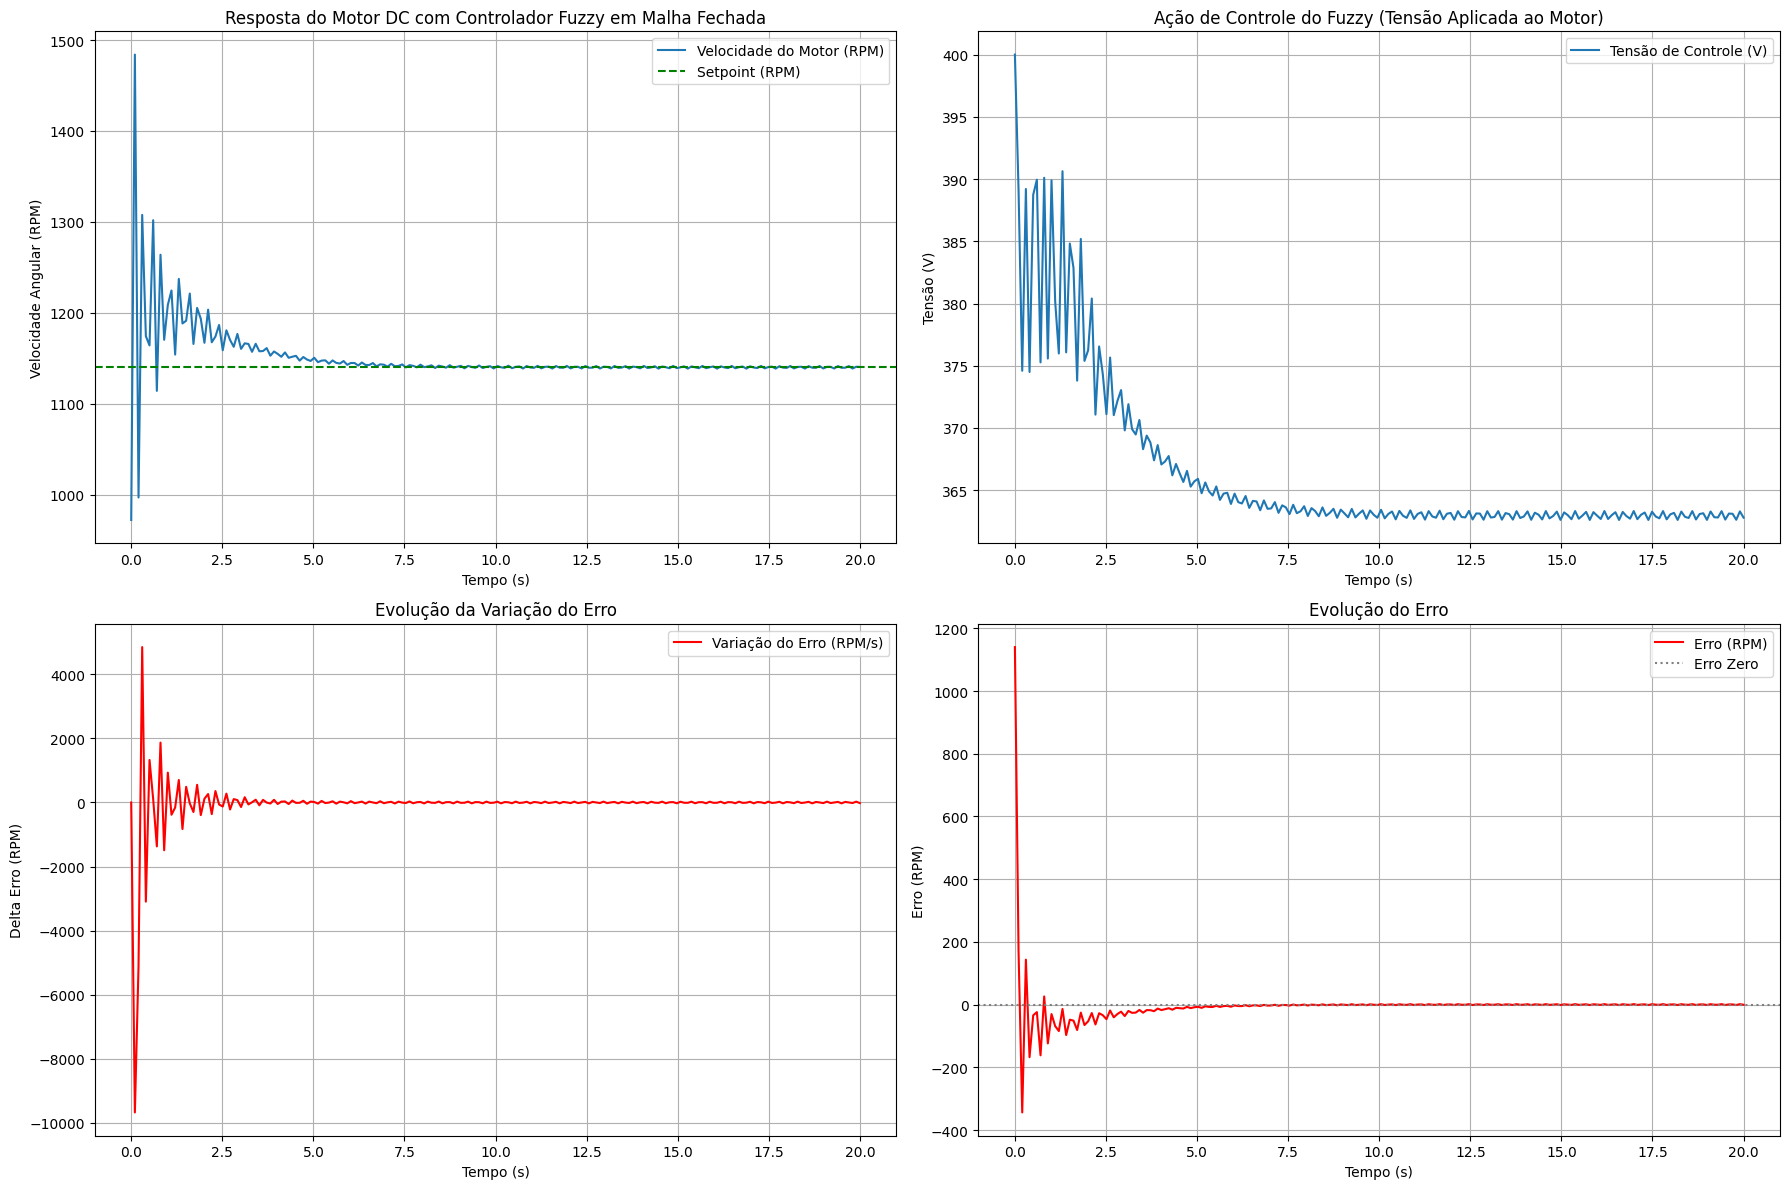

Setpoint: 1140.00 RPM
Velocidade final: 1140.37 RPM


In [ ]:
# Plotting the results
plt.figure(figsize=(18, 12)) # Adjusted figure size for a 2x2 layout, made a bit larger

plt.subplot(2, 2, 1) # First plot: Velocidade do Motor
plt.plot(time_closed_loop, motor_speed_rpm_history, label='Velocidade do Motor (RPM)')
plt.axhline(y=setpoint_rpm, color='g', linestyle='--', label='Setpoint (RPM)')
plt.title('Resposta do Motor DC com Controlador Fuzzy em Malha Fechada')
plt.xlabel('Tempo (s)')
plt.ylabel('Velocidade Angular (RPM)')
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 2) # Second plot: Tensão de Controle
plt.plot(time_closed_loop, control_voltage_history, label='Tensão de Controle (V)')
plt.title('Ação de Controle do Fuzzy (Tensão Aplicada ao Motor)')
plt.xlabel('Tempo (s)')
plt.ylabel('Tensão (V)')
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 3) # Third plot: Delta Erro
plt.plot(time_closed_loop, delta_error_history, label='Variação do Erro (RPM/s)', color='red')
plt.title('Evolução da Variação do Erro')
plt.xlabel('Tempo (s)')
plt.ylabel('Delta Erro (RPM)')
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 4) # Fourth plot: Erro
plt.plot(time_closed_loop, error_history, label='Erro (RPM)', color='red')
plt.axhline(y=0, color='gray', linestyle=':', label='Erro Zero')
plt.title('Evolução do Erro')
plt.xlabel('Tempo (s)')
plt.ylabel('Erro (RPM)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Setpoint: {setpoint_rpm:.2f} RPM")
print(f"Velocidade final: {motor_speed_rpm_history[-1]:.2f} RPM")

In [ ]:
#rule_dca = [
#    # dE = NG       NM          NS          ZE          PS          PM          PL
#    [d_control['NL'], d_control['NL'], d_control['NL'], d_control['NL'], d_control['NM'], d_control['NS'], d_control['ZE']], # E = NG
#    [d_control['NL'], d_control['NL'], d_control['NL'], d_control['NM'], d_control['NS'], d_control['ZE'], d_control['PS']], # E = NM
#    [d_control['NL'], d_control['NL'], d_control['NM'], d_control['NS'], d_control['ZE'], d_control['PS'], d_control['PM']], # E = NS
#    [d_control['NL'], d_control['NM'], d_control['NS'], d_control['ZE'], d_control['PS'], d_control['PM'], d_control['PL']], # E = ZE
#    [d_control['NM'], d_control['NS'], d_control['ZE'], d_control['PS'], d_control['PM'], d_control['PL'], d_control['PL']], # E = PS
#    [d_control['NS'], d_control['ZE'], d_control['PS'], d_control['PM'], d_control['PL'], d_control['PL'], d_control['PL']], # E = PM
#    [d_control['ZE'], d_control['PS'], d_control['PM'], d_control['PL'], d_control['PL'], d_control['PL'], d_control['PL']]  # E = PL
#]

A saída do controlador fuzzy, ou seja, o processo de **defuzzyficação**, não é dada por uma média geométrica neste caso. O `scikit-fuzzy`, por padrão, utiliza o método do **centroide** (Center of Gravity - CoG) para converter a saída fuzzy (os graus de pertinência das funções de saída) em um valor nítido (crisp value).

### Como funciona o método do Centroide:

1.  **Agregação das Regras**: Primeiro, as regras fuzzy ativadas (com base nas entradas 'Erro' e 'Delta Erro') são combinadas para formar uma única função de pertinência de saída fuzzy (para 'Delta Control Action').
2.  **Cálculo do Centroide**: O método do centroide calcula a área sob essa função de pertinência de saída agregada e encontra o ponto central (o "centro de massa") dessa área. Este ponto central é o valor nítido da saída.

Matematicamente, para uma função de pertinência $\mu_C(z)$ da variável de saída $z$, o centroide é calculado como:

$$ Z = \frac{\int \mu_C(z) z dz}{\int \mu_C(z) dz} $$

Este método é amplamente utilizado por sua robustez e por fornecer um valor que representa bem a distribuição da saída fuzzy. Existem outros métodos de defuzzyficação (como Bissetor, Média dos Máximos, Primeiro Máximo, Último Máximo), mas o centroide é o mais comum e é o padrão no `skfuzzy.ControlSystemSimulation` se você não especificar outro.

Se você quiser alterar o método de defuzzyficação, pode fazê-lo ao criar a simulação, por exemplo:

```python
fuzzy_sim = ctrl.ControlSystemSimulation(fuzzy_ctrl_system, defuzzify_method='mom') # Para Média dos Máximos
```